### Session 7

In [2]:
import kaggle
import os
import pandas as pd
kaggle.api.authenticate ()
kaggle.api.dataset_download_files(
    'shivamb/netflix-shows',
    path='data/raw/', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows


In [10]:
chess = pd.read_csv(os.path.join("data", "raw", "chess_games.csv"))

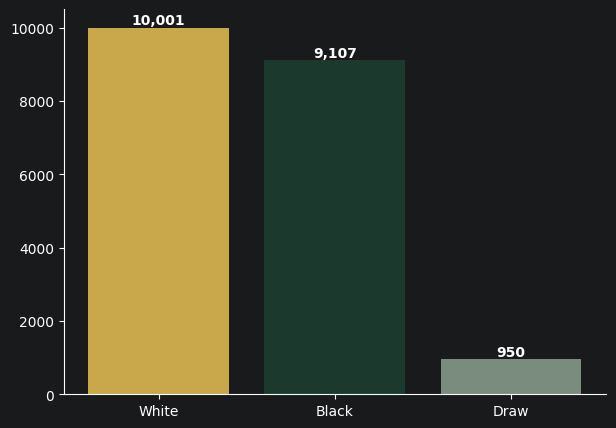

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 5))
counts = chess['winner'].value_counts()
bars = ax.bar(counts.index, counts.values,
             color=['#C9A84C','#1B3A2D','#7A8C7E'])
# Value labels
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2,
            h+80, f'{h:,}', ha='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

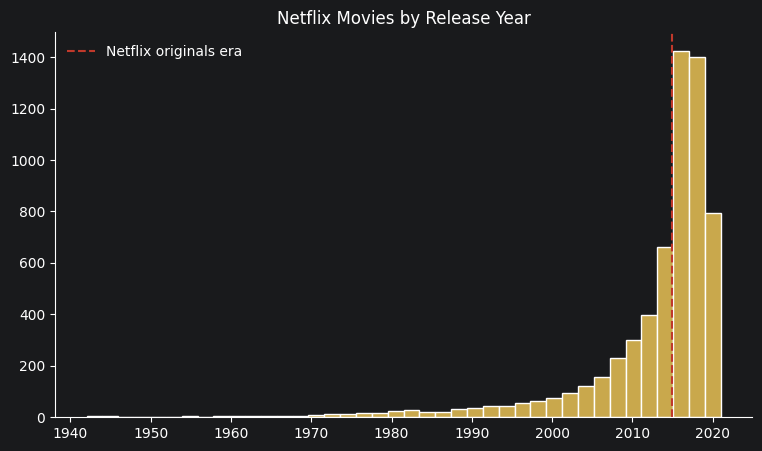

In [30]:
import matplotlib.pyplot as plt
netflix = pd.read_csv(os.path.join("data", "raw", "netflix_titles.csv"))
movies = netflix[netflix['type']=='Movie']
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(movies['release_year'].dropna(), bins=40,
        color='#C9A84C', edgecolor='white')
ax.axvline(x=2015, color='#C0392B', linewidth=1.5,
           linestyle='--', label='Netflix originals era')
ax.legend(frameon=False)
ax.set_title('Netflix Movies by Release Year')
ax.spines[['top','right']].set_visible(False)

In [5]:
# Temperature (323 annual rows, 1850–2025)
TEMP_ANNUAL = pd.read_csv('https://raw.githubusercontent.com/datasets/global-temp/main/data/annual.csv')
TEMP_ANNUAL.to_csv("data/raw/temp_annualy.csv", index=False)
TEMP_MONTHLY = pd.read_csv("https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv")
TEMP_MONTHLY.to_csv("data/raw/temp_monthly.csv", index=False)


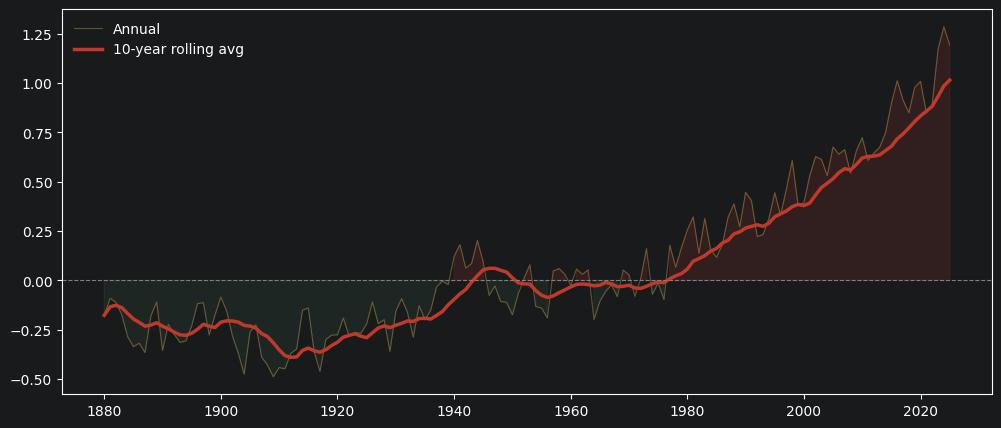

In [15]:
gistemp = TEMP_ANNUAL[TEMP_ANNUAL['Source']=='GISTEMP'].copy()
gistemp['rolling_10'] = gistemp['Mean'].rolling(10, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(12, 5))
# Raw annual values — noisy, light
ax.plot(gistemp['Year'], gistemp['Mean'],
        color='#C9A84C', alpha=0.4, linewidth=0.8, label='Annual')
# 10-year rolling — clear trend
ax.plot(gistemp['Year'], gistemp['rolling_10'],
        color='#C0392B', linewidth=2.5, label='10-year rolling avg')
# Zero baseline + shading
ax.axhline(y=0, color='grey', linewidth=0.8, linestyle='--')
ax.legend(frameon=False)
ax.fill_between(gistemp['Year'], 0, gistemp['Mean'],
                where=gistemp['Mean']>0, alpha=0.15, color='#C0392B', label='Above baseline')
ax.fill_between(gistemp['Year'], 0, gistemp['Mean'],
                where=gistemp['Mean']<=0, alpha=0.15, color='#3D6B4F', label='Below baseline')

C:\Users\pc\AppData\Local\Temp\ipykernel_14572\1845228605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=chess, x='victory_status',


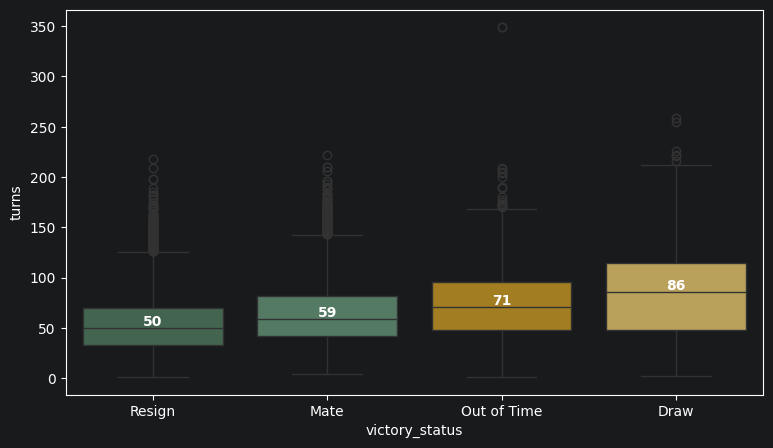

In [16]:
import seaborn as sns
order = ['Resign', 'Mate', 'Out of Time', 'Draw']
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=chess, x='victory_status',
            y='turns', order=order,
            palette=['#3D6B4F','#4E8063','#B8860B','#C9A84C'],
            ax=ax)
# Annotate medians
for i, status in enumerate(order):
    med = chess[chess['victory_status']==status]['turns'].median()
    ax.text(i, med+2, f'{med:.0f}', ha='center', color='white', fontweight='bold')

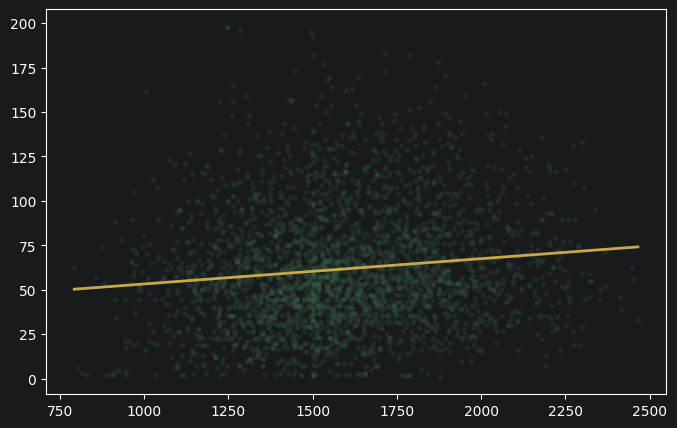

In [18]:
import numpy as np
rated = chess[chess['rated']==True].sample(3000, random_state=42)
corr  = rated['white_rating'].corr(rated['turns'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rated['white_rating'], rated['turns'],
           alpha=0.15, s=8, color='#3D6B4F')
# Trend line
z = np.polyfit(rated['white_rating'], rated['turns'], 1)
p = np.poly1d(z)
xl = np.linspace(rated['white_rating'].min(), rated['white_rating'].max(), 200)
ax.plot(xl, p(xl), color='#C9A84C', linewidth=2, label=f'r = {corr:.2f}')

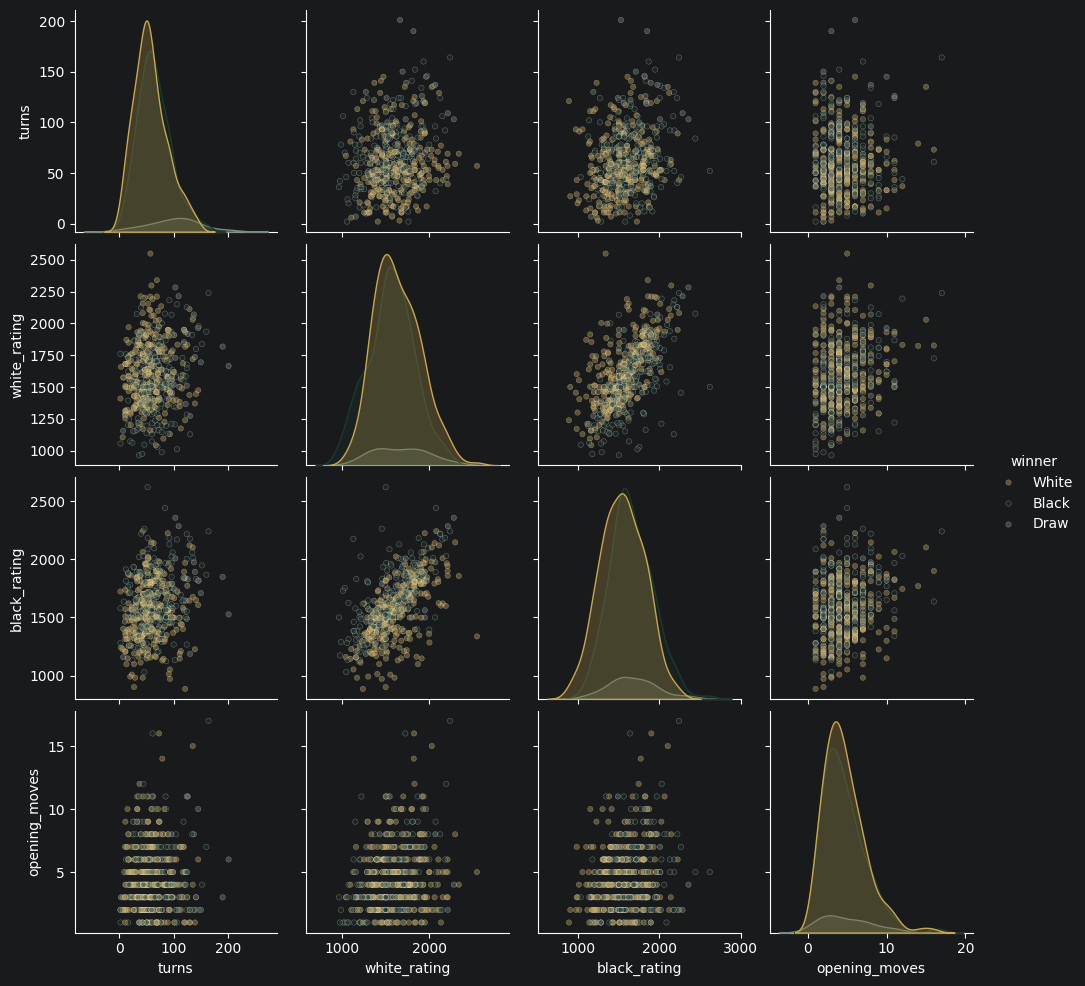

In [20]:
sample = chess[['turns','white_rating','black_rating','opening_moves','winner']].sample(500, random_state=42)
g = sns.pairplot(sample,
    hue='winner',
    palette={'White':'#C9A84C','Black':'#1B3A2D','Draw':'#7A8C7E'},
    plot_kws={'alpha':0.4, 's':15},
    diag_kind='kde')
# Reveals: white/black ratings are highly correlated

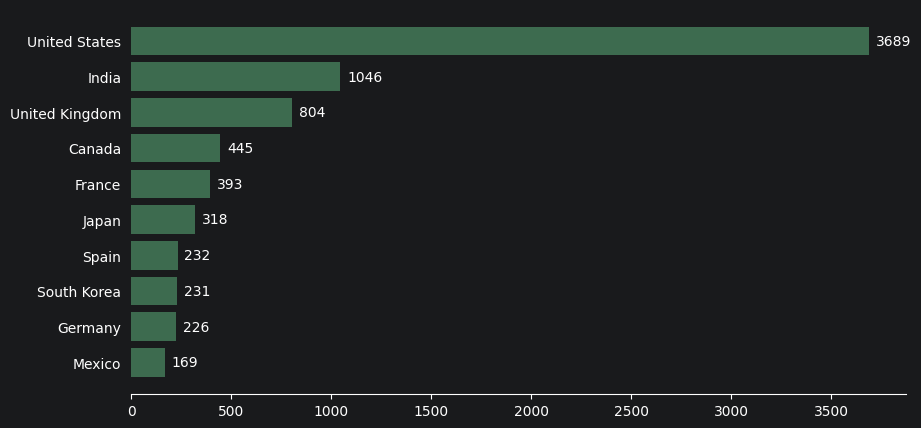

In [21]:
# Handle multi-country entries like 'US, India'
countries = (netflix['country'].dropna()
             .str.split(', ', expand=True)
             .stack().reset_index(drop=True)
             .rename('country').to_frame())
top10 = countries['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='#3D6B4F')
ax.bar_label(bars, padding=5)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)